# Road Traffic Accident Trends in India – Exploratory Data Analysis
**Data Source:** MoRTH (Ministry of Road Transport & Highways) datasets  
**Datasets:**
- `only_road_accidents_data_month2.csv` – Monthly accident counts by State/UT (2001–2014)
- `only_road_accidents_data3.csv` – Time-of-day accident counts by State/UT (2001–2014)

---

## 1. Imports & Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Global aesthetics
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams.update({
    'figure.dpi': 120,
    'axes.titlesize': 14,
    'axes.labelsize': 12,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
})
print("All libraries loaded successfully.")

All libraries loaded successfully.


## 2. Load & Inspect Datasets

In [2]:
# Dataset 1: Monthly accident distribution
df_month = pd.read_csv('only_road_accidents_data_month2.csv')

# Dataset 2: Time-of-day accident distribution
df_time  = pd.read_csv('only_road_accidents_data3.csv')

print("=" * 60)
print("Dataset 1 – Monthly Accidents")
print("=" * 60)
print(f"Shape : {df_month.shape}")
print(f"Years : {sorted(df_month['YEAR'].unique())}")
print(f"States: {df_month['STATE/UT'].nunique()} unique")
display(df_month.head())

print()
print("=" * 60)
print("Dataset 2 – Time-of-Day Accidents")
print("=" * 60)
print(f"Shape : {df_time.shape}")
display(df_time.head())

Dataset 1 – Monthly Accidents
Shape : (490, 15)
Years : [2001, 2002, 2003, 2004, 2005, 2006, 2007, 2008, 2009, 2010, 2011, 2012, 2013, 2014]
States: 37 unique


,STATE/UT,YEAR,JANUARY,FEBRUARY,MARCH,APRIL,MAY,JUNE,JULY,AUGUST,SEPTEMBER,OCTOBER,NOVEMBER,DECEMBER,TOTAL
0,A & N Islands,2001,8,23,15,15,14,19,14,19,7,12,13,22,181
1,A & N Islands,2002,12,10,14,16,10,7,16,11,23,21,11,17,168
2,A & N Islands,2003,19,13,15,13,13,12,8,16,17,25,14,15,180
3,A & N Islands,2004,21,14,22,17,13,18,16,19,16,20,15,24,215
4,A & N Islands,2005,19,21,22,17,13,19,21,14,15,19,10,16,206



Dataset 2 – Time-of-Day Accidents
Shape : (490, 11)


,STATE/UT,YEAR,0-3 hrs. (Night),3-6 hrs. (Night),6-9 hrs (Day),9-12 hrs (Day),12-15 hrs (Day),15-18 hrs (Day),18-21 hrs (Night),21-24 hrs (Night),Total
0,A & N Islands,2001,2,6,29,40,39,40,18,7,181
1,A & N Islands,2002,2,6,22,41,33,33,23,8,168
2,A & N Islands,2003,2,8,31,35,28,36,25,15,180
3,A & N Islands,2004,2,5,29,42,43,43,37,14,215
4,A & N Islands,2005,0,8,27,28,38,42,50,13,206


## 3. Data Quality & Cleaning

In [3]:
# ── Missing values
print("Missing values in df_month:")
print(df_month.isnull().sum())
print()
print("Missing values in df_time:")
print(df_time.isnull().sum())

Missing values in df_month:
STATE/UT     0
YEAR         0
JANUARY      0
FEBRUARY     0
MARCH        0
APRIL        0
MAY          0
JUNE         0
JULY         0
AUGUST       0
SEPTEMBER    0
OCTOBER      0
NOVEMBER     0
DECEMBER     0
TOTAL        0
dtype: int64

Missing values in df_time:
STATE/UT             0
YEAR                 0
0-3 hrs. (Night)     0
3-6 hrs. (Night)     0
6-9 hrs (Day)        0
9-12 hrs (Day)       0
12-15 hrs (Day)      0
15-18 hrs (Day)      0
18-21 hrs (Night)    0
21-24 hrs (Night)    0
Total                0
dtype: int64


In [4]:
# Found that state names were inconsistent across years (e.g. D&N Haveli 
# vs D & N Haveli) — normalised everything before proceeding.

In [5]:
# ── Schema normalisation: standardise state name inconsistencies
# e.g., 'D & N Haveli' vs 'D&N Haveli'
def normalise_state(name):
    return (name.strip()
                .replace('D & N Haveli', 'Dadra & Nagar Haveli')
                .replace('D&N Haveli',   'Dadra & Nagar Haveli')
                .replace('A & N Islands','Andaman & Nicobar Islands'))

df_month['STATE/UT'] = df_month['STATE/UT'].apply(normalise_state)
df_time['STATE/UT']  = df_time['STATE/UT'].apply(normalise_state)

print("Unique states after normalisation:", df_month['STATE/UT'].nunique())
print(sorted(df_month['STATE/UT'].unique()))

Unique states after normalisation: 36
['Andaman & Nicobar Islands', 'Andhra Pradesh', 'Arunachal Pradesh', 'Assam', 'Bihar', 'Chandigarh', 'Chhattisgarh', 'Dadra & Nagar Haveli', 'Daman & Diu', 'Delhi (Ut)', 'Delhi Ut', 'Goa', 'Gujarat', 'Haryana', 'Himachal Pradesh', 'Jammu & Kashmir', 'Jharkhand', 'Karnataka', 'Kerala', 'Lakshadweep', 'Madhya Pradesh', 'Maharashtra', 'Manipur', 'Meghalaya', 'Mizoram', 'Nagaland', 'Odisha', 'Puducherry', 'Punjab', 'Rajasthan', 'Sikkim', 'Tamil Nadu', 'Tripura', 'Uttar Pradesh', 'Uttarakhand', 'West Bengal']


In [6]:
# ── Basic statistics
print("df_month – Descriptive Statistics")
display(df_month.describe())

df_month – Descriptive Statistics


,YEAR,JANUARY,FEBRUARY,MARCH,APRIL,MAY,JUNE,JULY,AUGUST,SEPTEMBER,OCTOBER,NOVEMBER,DECEMBER,TOTAL
count,490.000000,490.000000,490.000000,490.000000,490.000000,490.000000,490.000000,490.000000,490.000000,490.000000,490.000000,490.000000,490.000000,490.000000
mean,2007.500000,985.140816,937.289796,992.124490,978.904082,1064.414286,966.477551,898.495918,894.593878,888.371429,928.491837,933.044898,967.153061,11434.502041
std,4.035249,1403.961467,1326.928970,1403.445117,1397.371515,1508.166230,1345.067531,1245.805847,1263.668002,1250.579984,1274.226151,1269.391981,1337.868111,15948.689470
min,2001.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2004.000000,31.000000,30.000000,32.250000,25.250000,32.250000,28.000000,28.250000,28.500000,27.750000,30.250000,28.250000,30.000000,357.750000
50%,2007.500000,329.500000,348.500000,369.000000,350.000000,387.500000,342.500000,308.000000,313.000000,311.500000,311.500000,331.000000,347.500000,4174.500000
75%,2011.000000,1513.500000,1394.250000,1381.000000,1356.250000,1464.000000,1384.000000,1301.500000,1222.250000,1227.500000,1287.000000,1246.500000,1365.250000,16463.500000
max,2014.000000,9062.000000,8705.000000,9205.000000,9006.000000,9330.000000,5915.000000,5719.000000,5936.000000,5777.000000,5516.000000,5367.000000,5562.000000,75480.000000


## 4. Feature Engineering

In [7]:
# ── Derived features for df_month
months = ['JANUARY','FEBRUARY','MARCH','APRIL','MAY','JUNE',
          'JULY','AUGUST','SEPTEMBER','OCTOBER','NOVEMBER','DECEMBER']

# Peak month per row
df_month['PEAK_MONTH']  = df_month[months].idxmax(axis=1)

# Seasonal groupings
df_month['WINTER']  = df_month[['DECEMBER','JANUARY','FEBRUARY']].sum(axis=1)
df_month['SUMMER']  = df_month[['MARCH','APRIL','MAY']].sum(axis=1)
df_month['MONSOON'] = df_month[['JUNE','JULY','AUGUST','SEPTEMBER']].sum(axis=1)
df_month['AUTUMN']  = df_month[['OCTOBER','NOVEMBER']].sum(axis=1)

# Monthly coefficient of variation (seasonality index)
df_month['MONTH_CV'] = df_month[months].std(axis=1) / df_month[months].mean(axis=1)

# ── Derived features for df_time
time_cols_day   = ['6-9 hrs (Day)','9-12 hrs (Day)','12-15 hrs (Day)','15-18 hrs (Day)']
time_cols_night = ['0-3 hrs. (Night)','3-6 hrs. (Night)','18-21 hrs (Night)','21-24 hrs (Night)']

df_time['DAY_TOTAL']   = df_time[time_cols_day].sum(axis=1)
df_time['NIGHT_TOTAL'] = df_time[time_cols_night].sum(axis=1)
df_time['NIGHT_RATIO'] = df_time['NIGHT_TOTAL'] / df_time['Total']
df_time['PEAK_HOUR_SLOT'] = df_time[time_cols_day + time_cols_night].idxmax(axis=1)

print("Feature engineering complete.")
print("New columns in df_month:", [c for c in df_month.columns if c not in ['STATE/UT','YEAR'] + months + ['TOTAL']])
print("New columns in df_time :", [c for c in df_time.columns  if c not in ['STATE/UT','YEAR','Total'] + time_cols_day + time_cols_night])

Feature engineering complete.
New columns in df_month: ['PEAK_MONTH', 'WINTER', 'SUMMER', 'MONSOON', 'AUTUMN', 'MONTH_CV']
New columns in df_time : ['DAY_TOTAL', 'NIGHT_TOTAL', 'NIGHT_RATIO', 'PEAK_HOUR_SLOT']


## 5. National Trend – Accidents Over Time (2001–2014)

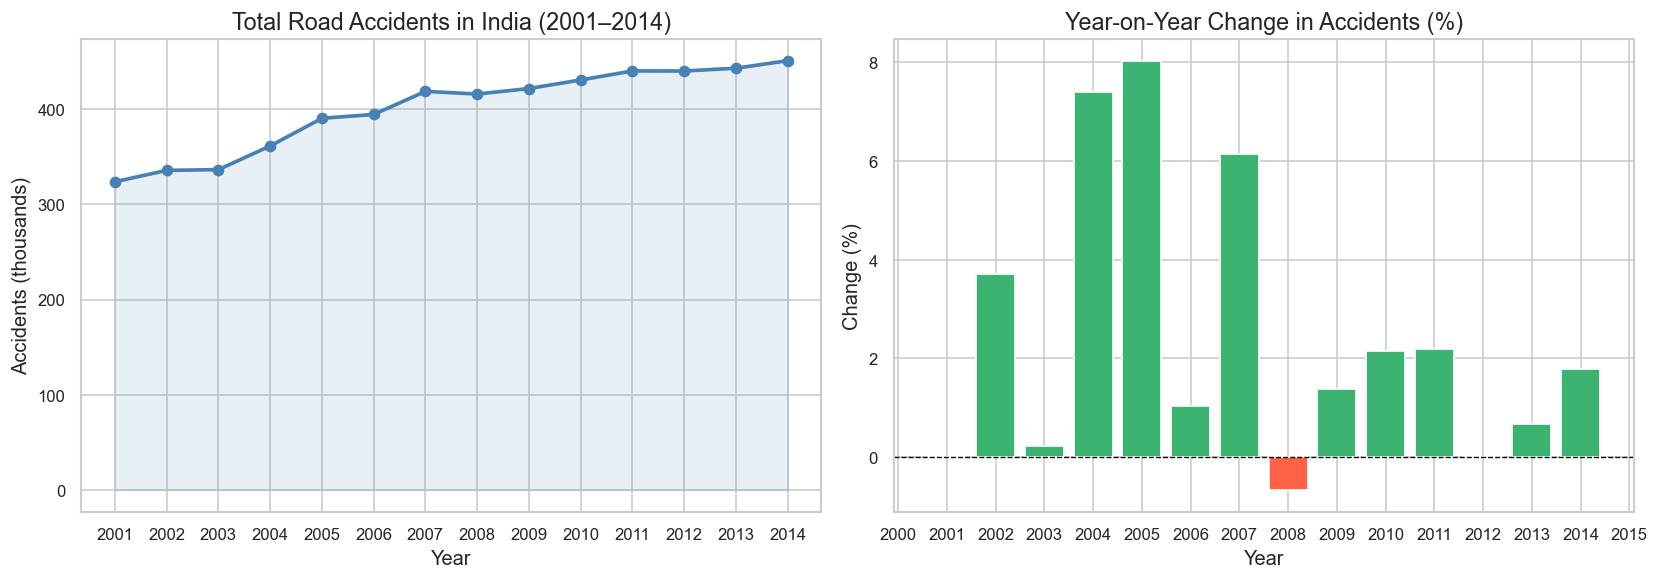

Peak year: 2014 with 450898 accidents


In [8]:
annual = df_month.groupby('YEAR')['TOTAL'].sum().reset_index()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Absolute trend
ax = axes[0]
ax.plot(annual['YEAR'], annual['TOTAL']/1e3, marker='o', color='steelblue', linewidth=2.2)
ax.fill_between(annual['YEAR'], annual['TOTAL']/1e3, alpha=0.12, color='steelblue')
ax.set_title('Total Road Accidents in India (2001–2014)')
ax.set_xlabel('Year'); ax.set_ylabel('Accidents (thousands)')
ax.xaxis.set_major_locator(mticker.MultipleLocator(1))

# Year-on-year % change
annual['YOY_CHANGE'] = annual['TOTAL'].pct_change() * 100
ax2 = axes[1]
colors = ['tomato' if v < 0 else 'mediumseagreen' for v in annual['YOY_CHANGE'].fillna(0)]
ax2.bar(annual['YEAR'], annual['YOY_CHANGE'].fillna(0), color=colors, edgecolor='white')
ax2.axhline(0, color='black', linewidth=0.8, linestyle='--')
ax2.set_title('Year-on-Year Change in Accidents (%)')
ax2.set_xlabel('Year'); ax2.set_ylabel('Change (%)')
ax2.xaxis.set_major_locator(mticker.MultipleLocator(1))

plt.tight_layout()
plt.savefig('fig01_national_trend.png', bbox_inches='tight')
plt.show()
print("Peak year:", annual.loc[annual['TOTAL'].idxmax(), 'YEAR'],
      "with", annual['TOTAL'].max(), "accidents")

## 6. Geographic Distribution – State-wise Analysis

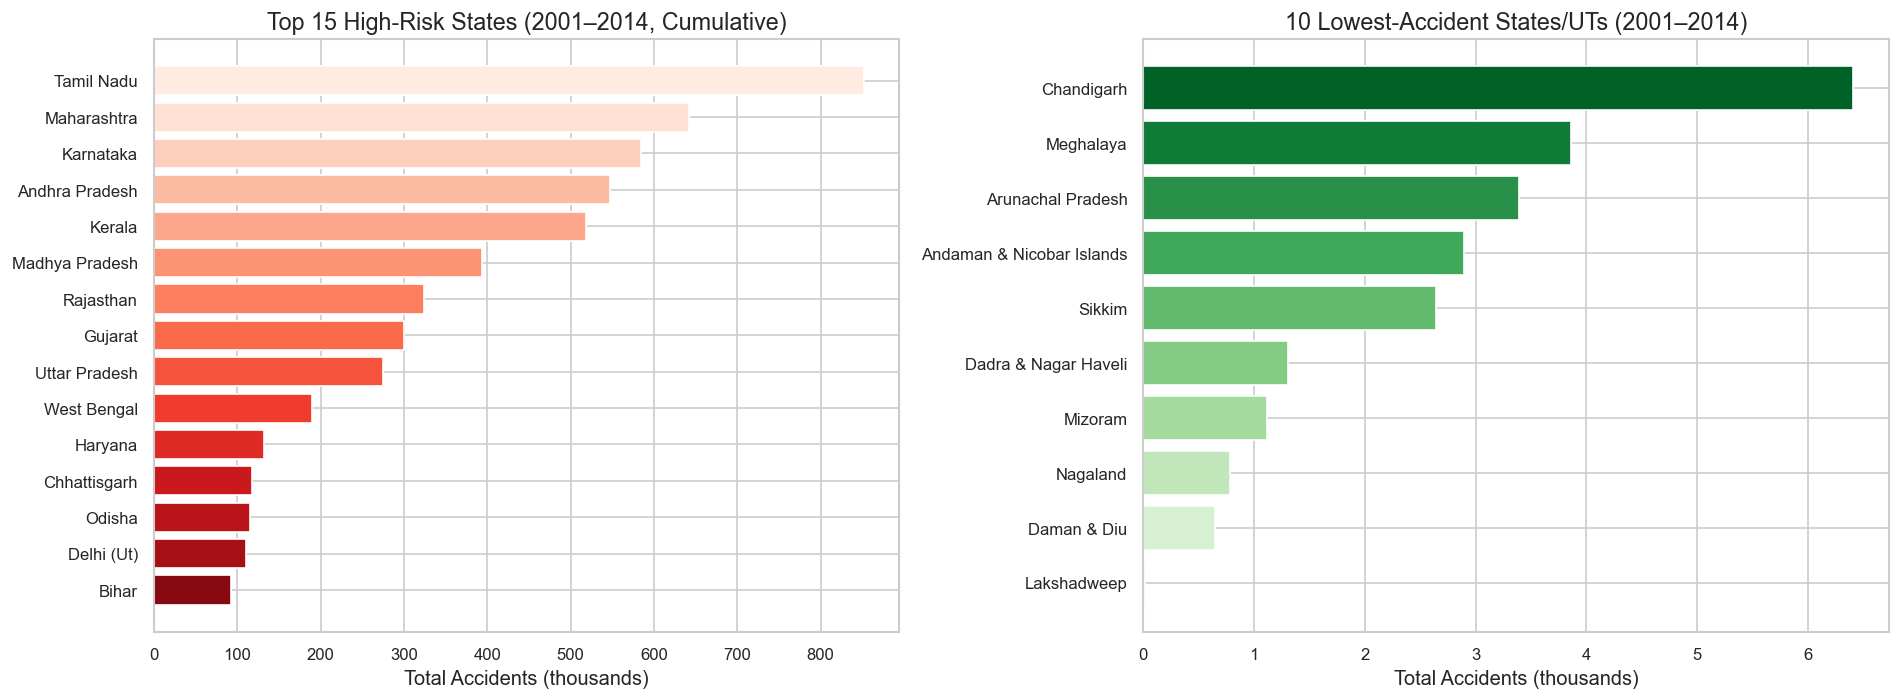

In [9]:
state_total = df_month.groupby('STATE/UT')['TOTAL'].sum().sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Top 15 states – bar chart
top15 = state_total.head(15)
axes[0].barh(top15.index[::-1], top15.values[::-1]/1e3, color=sns.color_palette('Reds_r', 15))
axes[0].set_title('Top 15 High-Risk States (2001–2014, Cumulative)')
axes[0].set_xlabel('Total Accidents (thousands)')

# Bottom 10 (low-accident states)
bot10 = state_total.tail(10)
axes[1].barh(bot10.index[::-1], bot10.values[::-1]/1e3, color=sns.color_palette('Greens', 10))
axes[1].set_title('10 Lowest-Accident States/UTs (2001–2014)')
axes[1].set_xlabel('Total Accidents (thousands)')

plt.tight_layout()
plt.savefig('fig02_state_distribution.png', bbox_inches='tight')
plt.show()

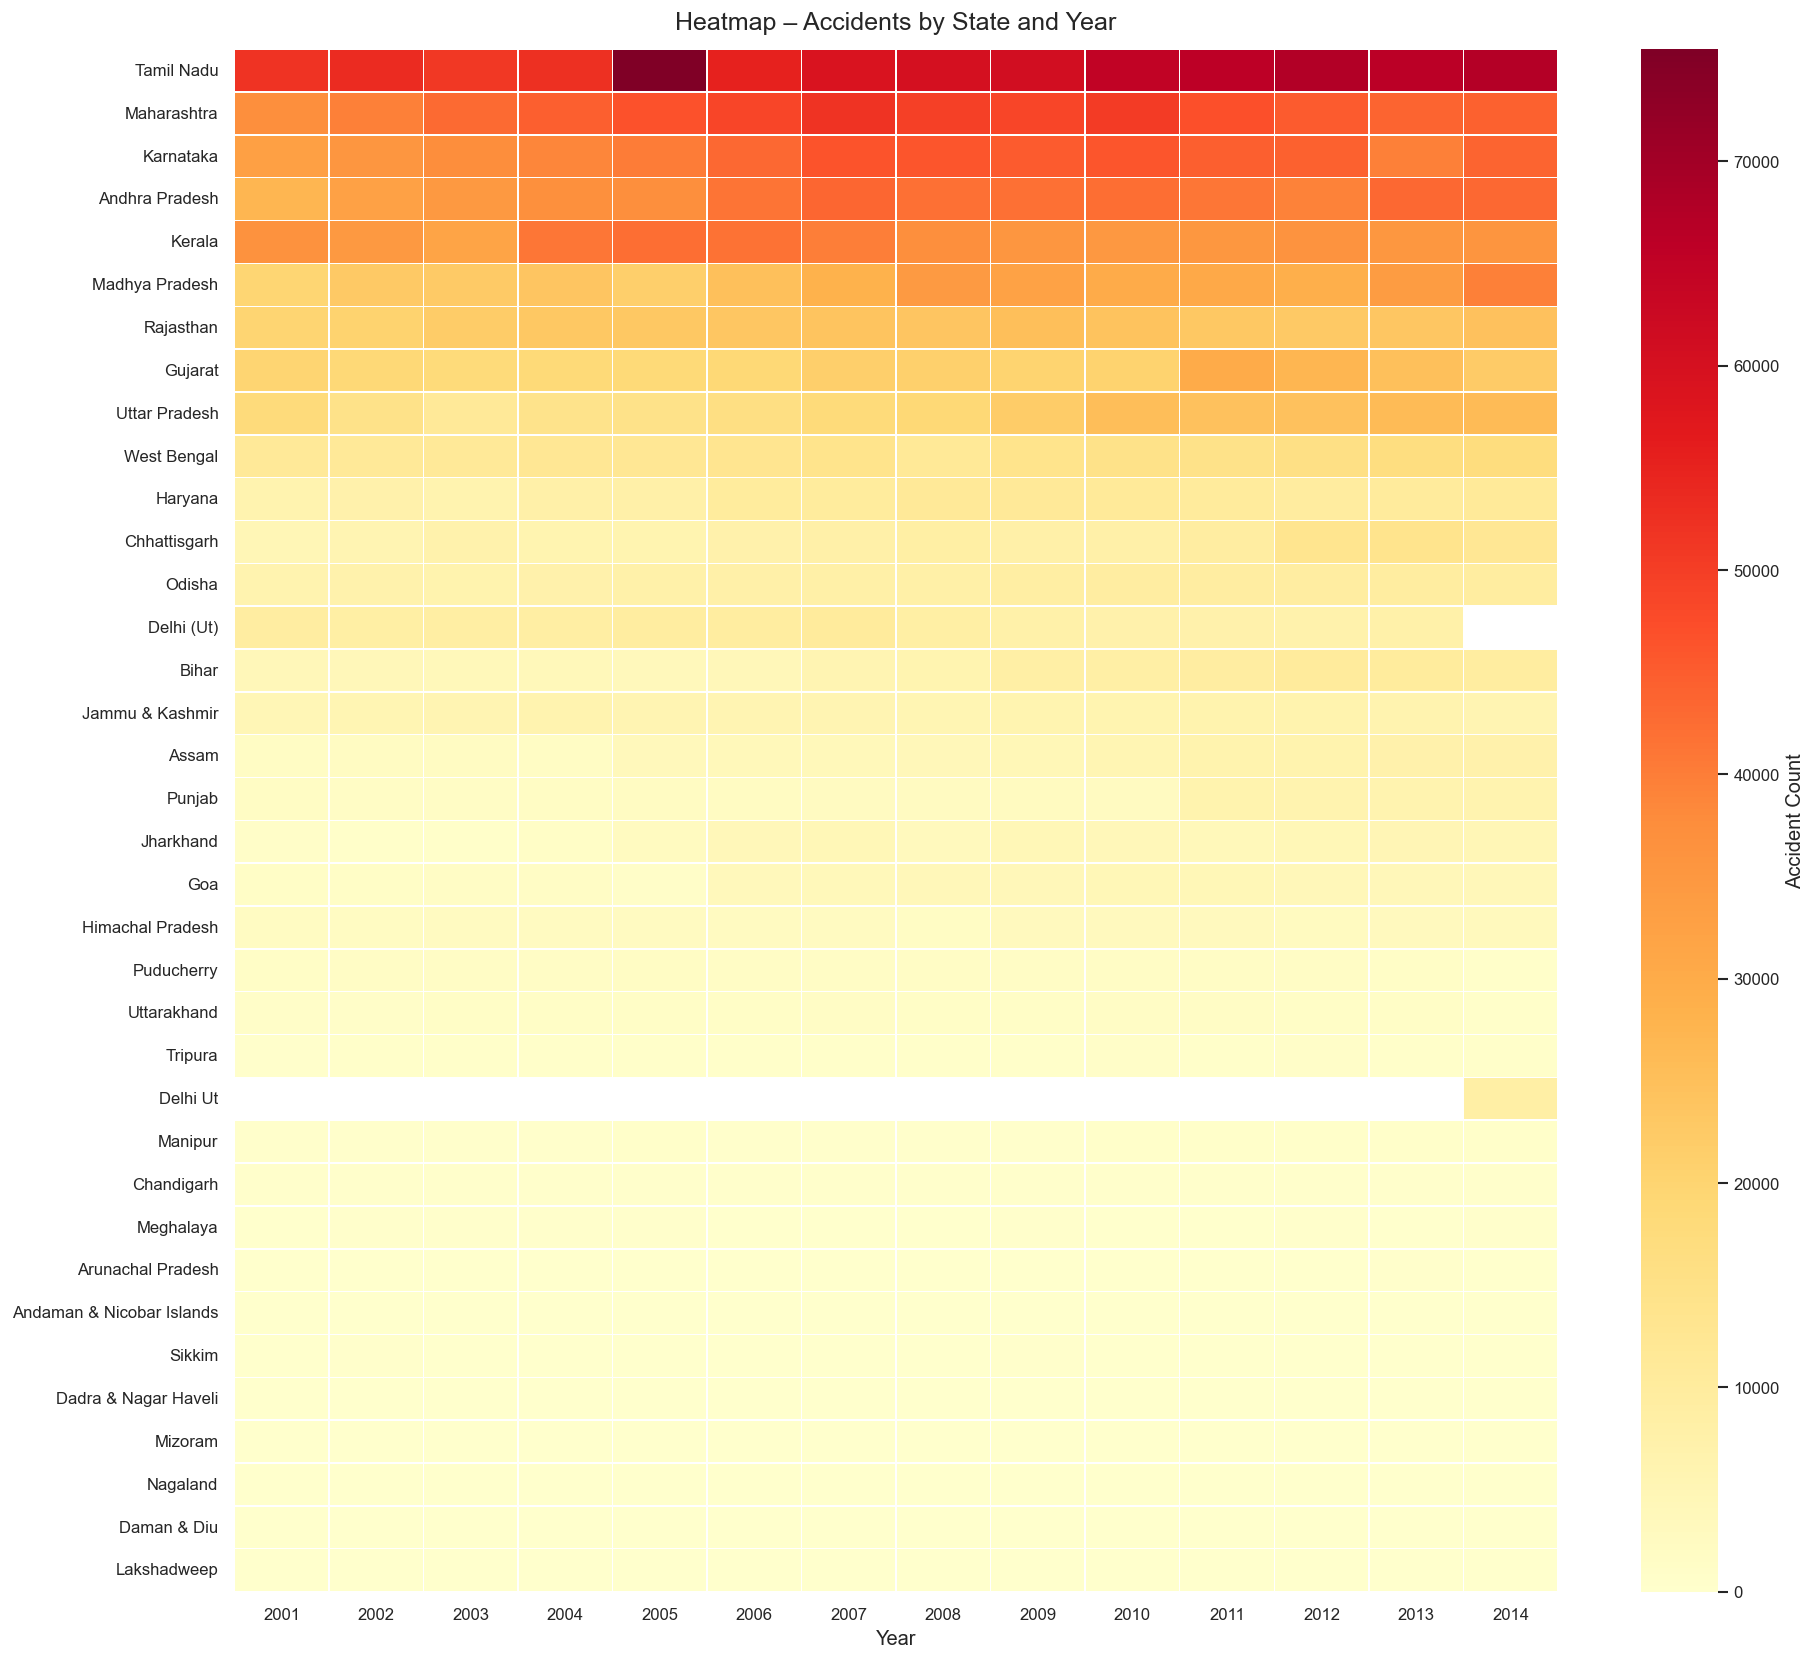

In [10]:
# Choropleth-style heatmap: State × Year
pivot_state_year = df_month.pivot_table(
    index='STATE/UT', columns='YEAR', values='TOTAL', aggfunc='sum')

# Sort by total descending for readability
pivot_state_year = pivot_state_year.loc[
    pivot_state_year.sum(axis=1).sort_values(ascending=False).index]

fig, ax = plt.subplots(figsize=(16, 14))
sns.heatmap(pivot_state_year, cmap='YlOrRd', linewidths=0.3,
            fmt='.0f', annot=False, cbar_kws={'label': 'Accident Count'}, ax=ax)
ax.set_title('Heatmap – Accidents by State and Year', fontsize=15, pad=12)
ax.set_xlabel('Year'); ax.set_ylabel('')
plt.tight_layout()
plt.savefig('fig03_state_year_heatmap.png', bbox_inches='tight')
plt.show()

In [11]:
#accidents increase each year in each state

## 7. Seasonal & Monthly Patterns

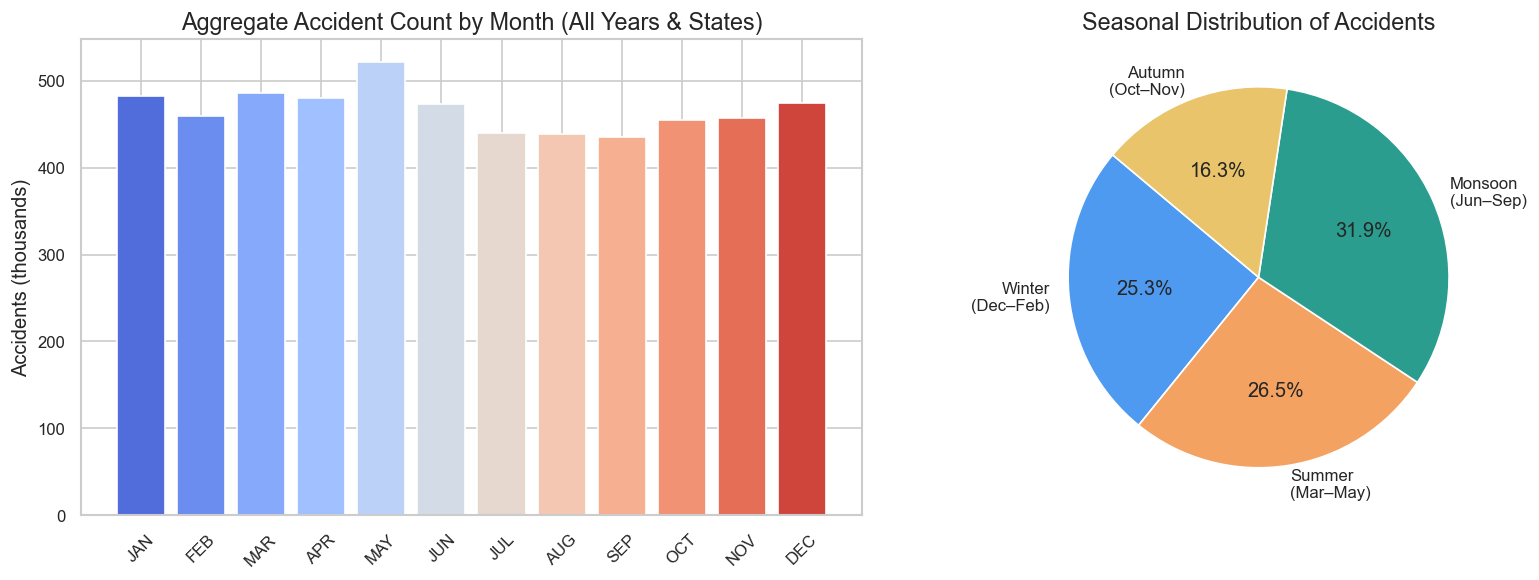

Month with highest accidents: MAY
Month with lowest accidents: SEPTEMBER


In [12]:
month_totals = df_month[months].sum()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Monthly bar chart
axes[0].bar(
    range(1, 13),
    month_totals.values / 1e3,
    color=sns.color_palette('coolwarm', 12)
)

axes[0].set_xticks(range(1, 13))
axes[0].set_xticklabels([m[:3] for m in months], rotation=45)
axes[0].set_title('Aggregate Accident Count by Month (All Years & States)')
axes[0].set_ylabel('Accidents (thousands)')

# Seasonal pie chart
season_totals = {
    'Winter\n(Dec–Feb)': df_month['WINTER'].sum(),
    'Summer\n(Mar–May)': df_month['SUMMER'].sum(),
    'Monsoon\n(Jun–Sep)': df_month['MONSOON'].sum(),
    'Autumn\n(Oct–Nov)': df_month['AUTUMN'].sum(),
}

axes[1].pie(
    season_totals.values(),
    labels=season_totals.keys(),
    autopct='%1.1f%%',
    startangle=140,
    colors=['#4e9af1', '#f4a261', '#2a9d8f', '#e9c46a']
)

axes[1].set_title('Seasonal Distribution of Accidents')

plt.tight_layout()
plt.savefig('fig04_monthly_seasonal.png', bbox_inches='tight')
plt.show()

print("Month with highest accidents:", months[month_totals.argmax()])
print("Month with lowest accidents:", months[month_totals.argmin()])

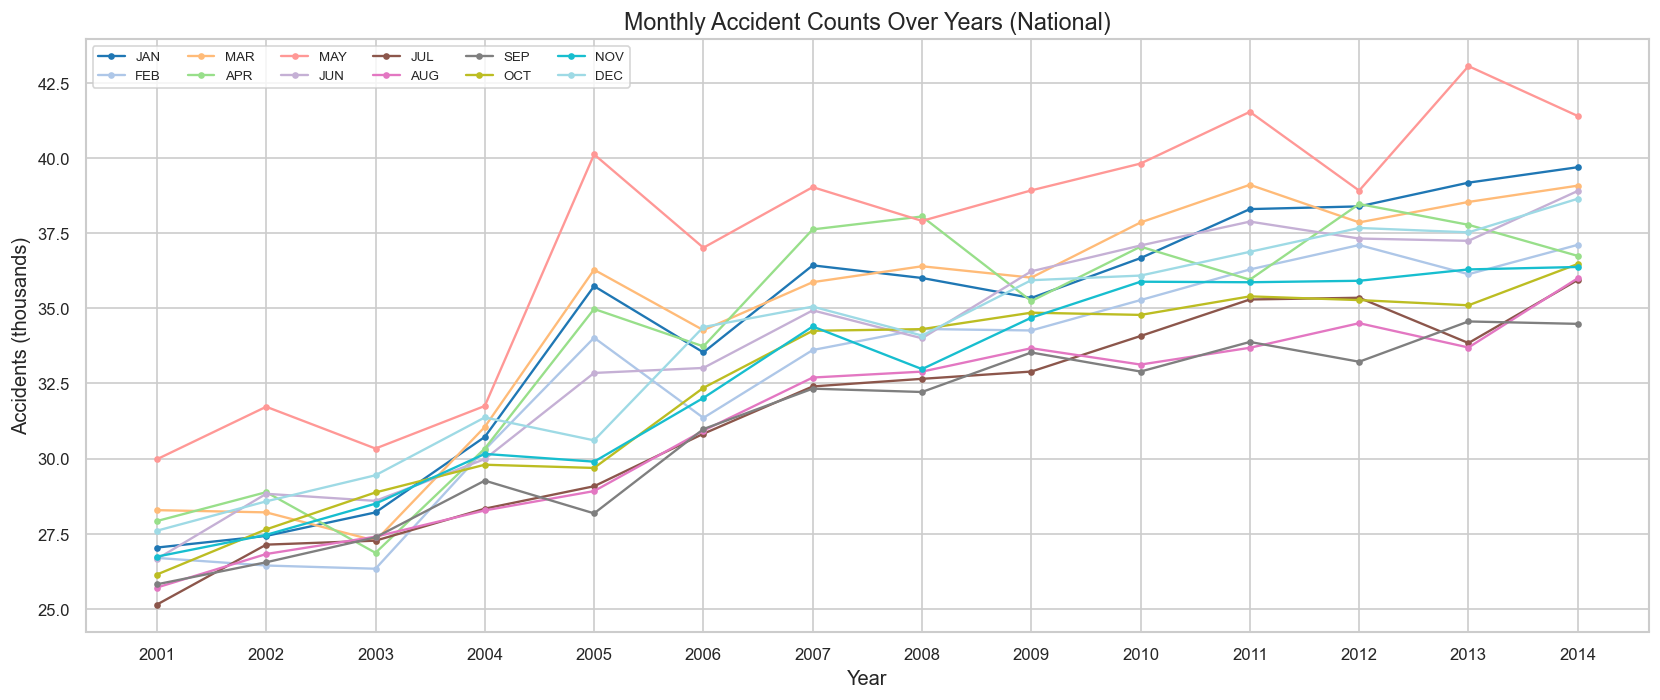

In [13]:
# Monthly trend by year (line chart per month)
monthly_by_year = df_month.groupby('YEAR')[months].sum()

fig, ax = plt.subplots(figsize=(14, 6))
cmap = plt.cm.get_cmap('tab20', 12)
for i, m in enumerate(months):
    ax.plot(monthly_by_year.index, monthly_by_year[m]/1e3,
            marker='o', markersize=3, label=m[:3], color=cmap(i), linewidth=1.4)
ax.set_title('Monthly Accident Counts Over Years (National)')
ax.set_xlabel('Year'); ax.set_ylabel('Accidents (thousands)')
ax.legend(ncol=6, loc='upper left', fontsize=8)
ax.xaxis.set_major_locator(mticker.MultipleLocator(1))
plt.tight_layout()
plt.savefig('fig05_monthly_trend_lines.png', bbox_inches='tight')
plt.show()

## 8. Time-of-Day Analysis

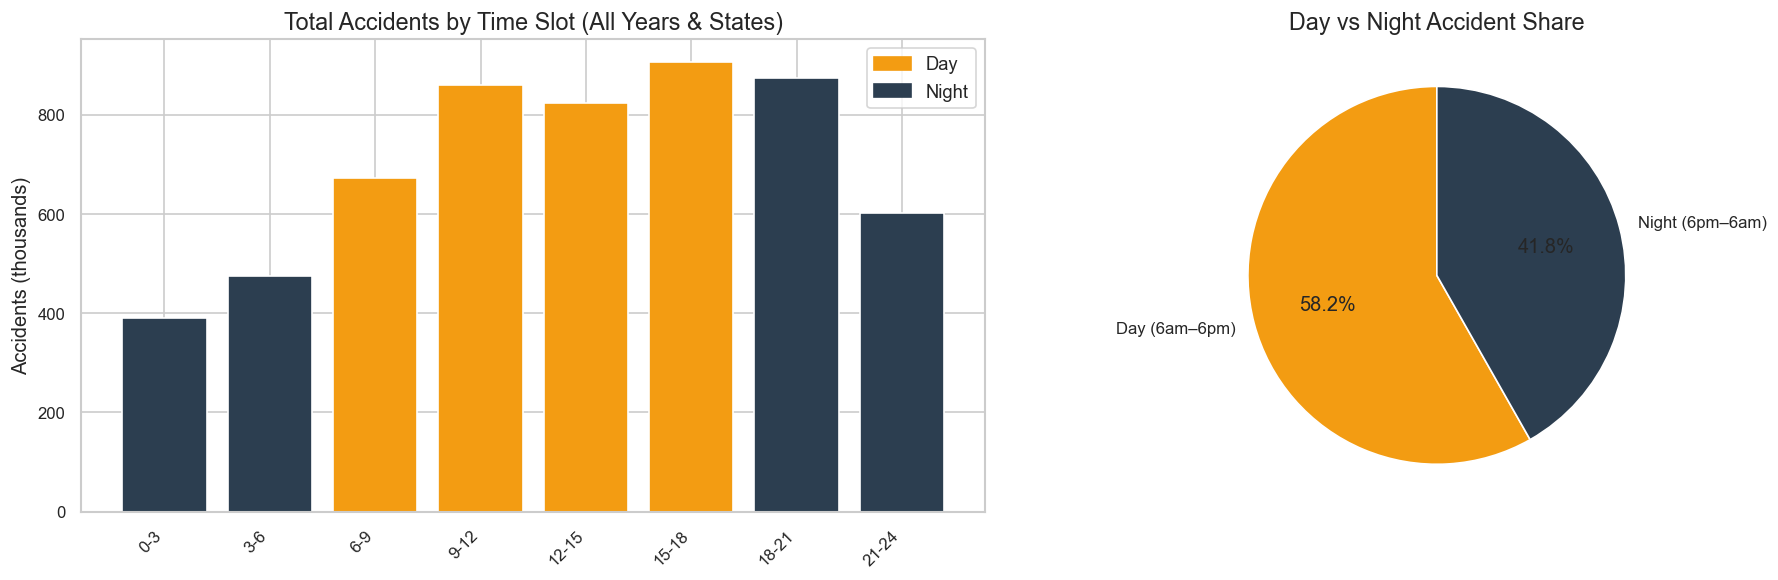

Day  accidents: 3,262,036
Night accidents: 2,340,870
Night share: 41.8%


In [14]:
all_slots = ['0-3 hrs. (Night)','3-6 hrs. (Night)',
             '6-9 hrs (Day)','9-12 hrs (Day)','12-15 hrs (Day)',
             '15-18 hrs (Day)','18-21 hrs (Night)','21-24 hrs (Night)']

slot_totals = df_time[all_slots].sum()
is_night    = [True, True, False, False, False, False, True, True]
bar_colors  = ['#2c3e50' if n else '#f39c12' for n in is_night]

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].bar(range(len(all_slots)), slot_totals.values/1e3, color=bar_colors)
axes[0].set_xticks(range(len(all_slots)))
axes[0].set_xticklabels([s.split(' ')[0] for s in all_slots], rotation=45, ha='right')
axes[0].set_title('Total Accidents by Time Slot (All Years & States)')
axes[0].set_ylabel('Accidents (thousands)')
from matplotlib.patches import Patch
axes[0].legend(handles=[Patch(color='#f39c12', label='Day'),
                         Patch(color='#2c3e50', label='Night')])

# Day vs Night overall
day_total   = slot_totals[['6-9 hrs (Day)','9-12 hrs (Day)','12-15 hrs (Day)','15-18 hrs (Day)']].sum()
night_total = slot_totals[['0-3 hrs. (Night)','3-6 hrs. (Night)','18-21 hrs (Night)','21-24 hrs (Night)']].sum()
axes[1].pie([day_total, night_total], labels=['Day (6am–6pm)', 'Night (6pm–6am)'],
            autopct='%1.1f%%', colors=['#f39c12','#2c3e50'], startangle=90)
axes[1].set_title('Day vs Night Accident Share')

plt.tight_layout()
plt.savefig('fig06_time_of_day.png', bbox_inches='tight')
plt.show()
print(f"Day  accidents: {day_total:,}")
print(f"Night accidents: {night_total:,}")
print(f"Night share: {night_total/(day_total+night_total)*100:.1f}%")

## 9. High-Risk Corridors – Identifying Peak Accident Windows by State

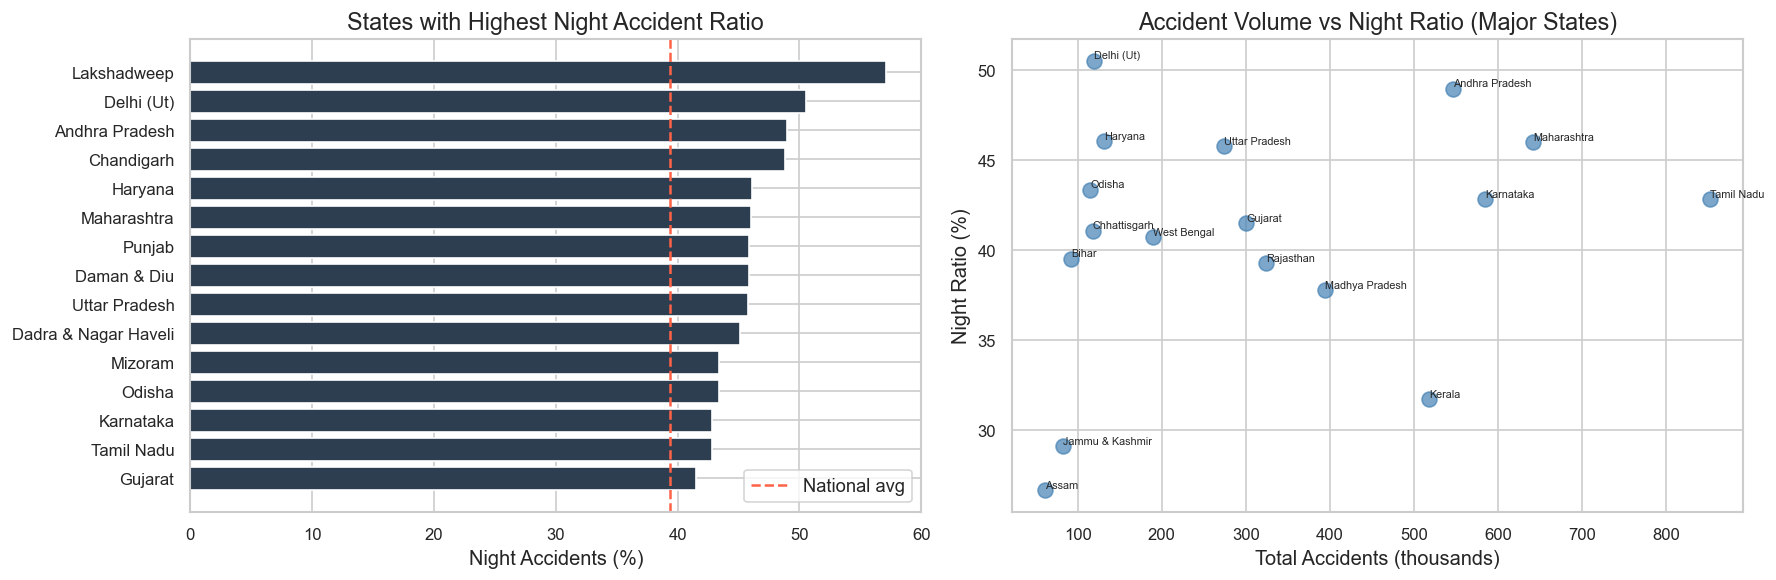

In [15]:
# States with highest night-time accident ratio
state_night = df_time.groupby('STATE/UT')[['DAY_TOTAL','NIGHT_TOTAL','Total']].sum()
state_night['NIGHT_RATIO'] = state_night['NIGHT_TOTAL'] / state_night['Total']
state_night_sorted = state_night.sort_values('NIGHT_RATIO', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Top 15 states by night ratio
top15_night = state_night_sorted.head(15)
axes[0].barh(top15_night.index[::-1], top15_night['NIGHT_RATIO'][::-1]*100,
             color='#2c3e50')
axes[0].set_title('States with Highest Night Accident Ratio')
axes[0].set_xlabel('Night Accidents (%)')
axes[0].axvline(state_night['NIGHT_RATIO'].mean()*100, color='tomato',
                linestyle='--', label='National avg')
axes[0].legend()

# Scatter: Total accidents vs Night ratio
major_states = state_night[state_night['Total'] > 50000]
axes[1].scatter(major_states['Total']/1e3, major_states['NIGHT_RATIO']*100,
                s=80, alpha=0.7, color='steelblue')
for idx, row in major_states.iterrows():
    axes[1].annotate(idx, (row['Total']/1e3, row['NIGHT_RATIO']*100),
                     fontsize=6.5, ha='left', va='bottom')
axes[1].set_title('Accident Volume vs Night Ratio (Major States)')
axes[1].set_xlabel('Total Accidents (thousands)')
axes[1].set_ylabel('Night Ratio (%)')

plt.tight_layout()
plt.savefig('fig07_night_risk.png', bbox_inches='tight')
plt.show()

## 10. Time-Series Decomposition – Trend, Seasonality & Residuals

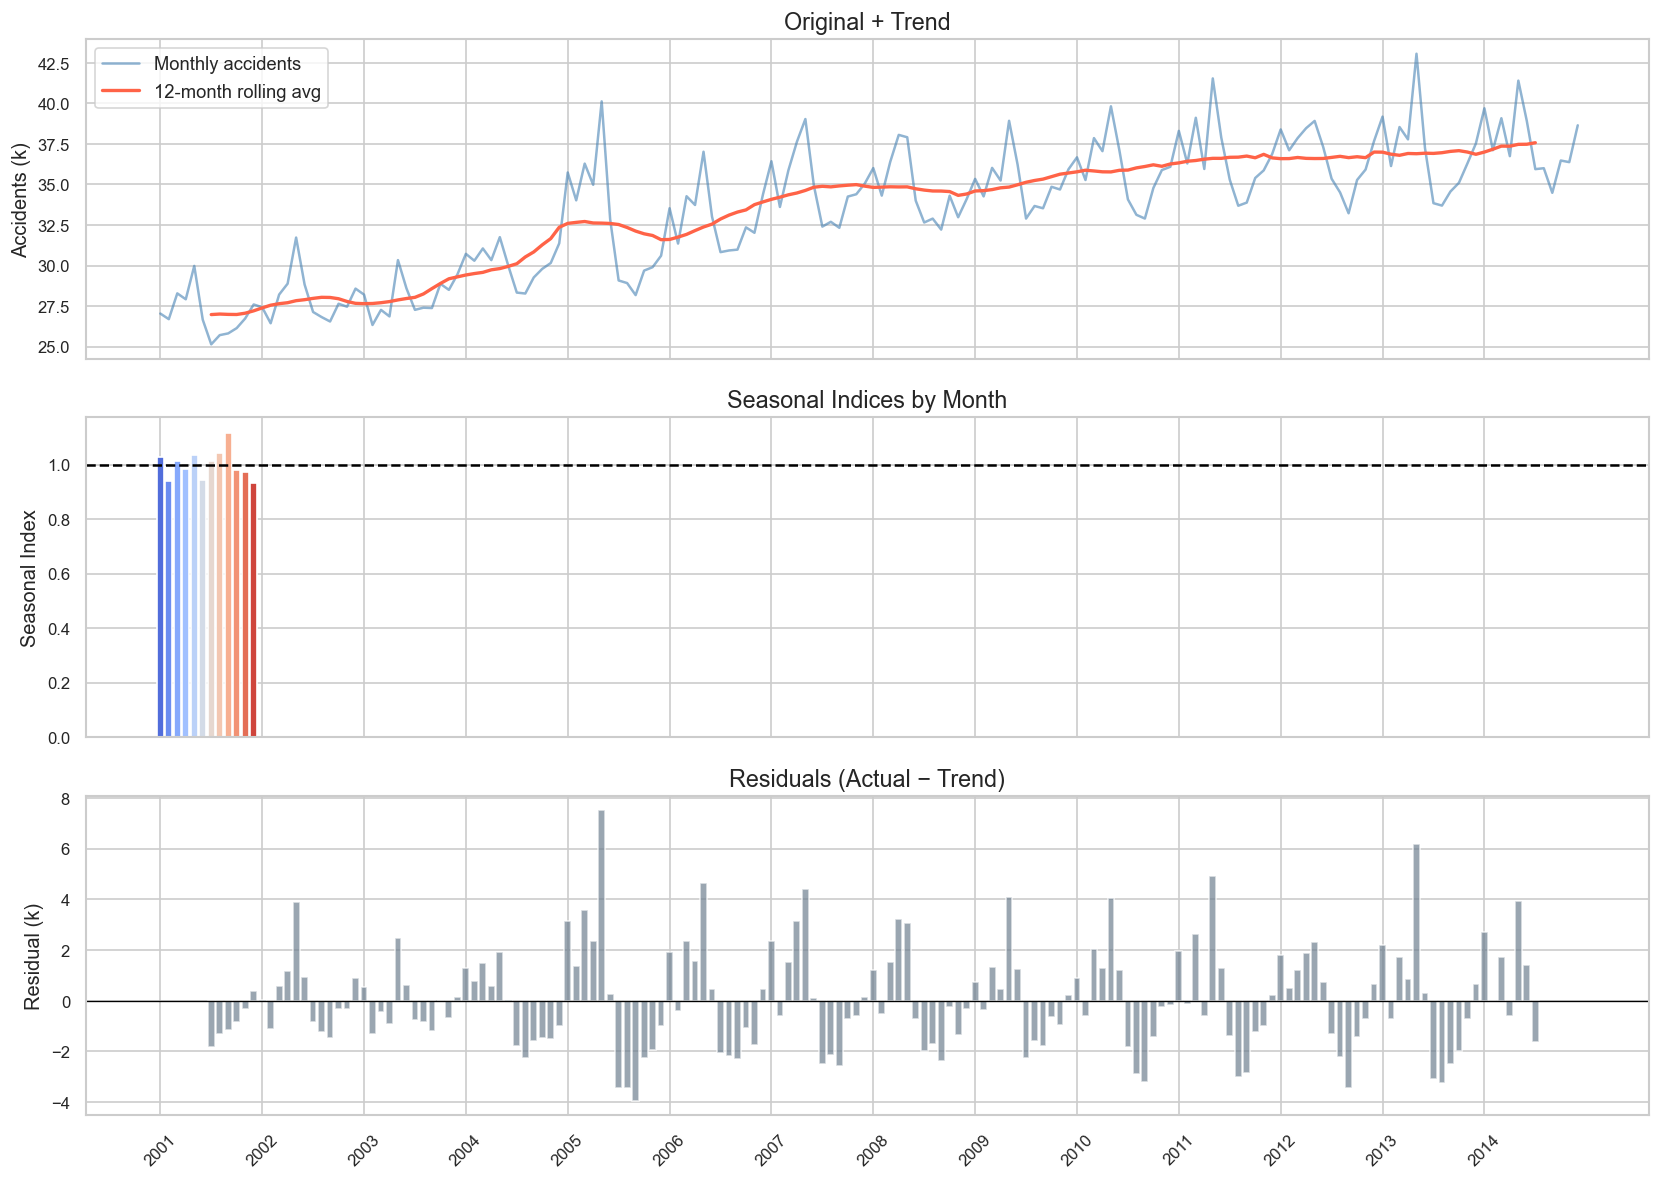

In [16]:
# Build a monthly national time-series (all states combined)
ts_data = df_month.groupby('YEAR')[months].sum()

# Melt into long format for trend analysis
ts_long = ts_data.reset_index().melt(id_vars='YEAR', var_name='MONTH', value_name='ACCIDENTS')
month_order = {m: i+1 for i, m in enumerate(months)}
ts_long['MONTH_NUM'] = ts_long['MONTH'].map(month_order)
ts_long = ts_long.sort_values(['YEAR','MONTH_NUM'])
ts_long['TIME_IDX'] = range(len(ts_long))

# Rolling 12-month average (trend)
ts_long['TREND'] = ts_long['ACCIDENTS'].rolling(12, center=True).mean()

# Seasonal index per month
seasonal_avg = ts_long.groupby('MONTH')['ACCIDENTS'].mean()
overall_avg  = ts_long['ACCIDENTS'].mean()
ts_long['SEASONAL_INDEX'] = ts_long['MONTH'].map(seasonal_avg) / overall_avg

fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)

axes[0].plot(ts_long['TIME_IDX'], ts_long['ACCIDENTS']/1e3, color='steelblue',
             alpha=0.6, label='Monthly accidents')
axes[0].plot(ts_long['TIME_IDX'], ts_long['TREND']/1e3, color='tomato',
             linewidth=2, label='12-month rolling avg')
axes[0].set_ylabel('Accidents (k)'); axes[0].set_title('Original + Trend')
axes[0].legend()

axes[1].bar(range(12), seasonal_avg.values/overall_avg,
            color=sns.color_palette('coolwarm', 12))
axes[1].axhline(1, color='black', linestyle='--')
axes[1].set_xticks(range(12))
axes[1].set_xticklabels([m[:3] for m in months])
axes[1].set_ylabel('Seasonal Index'); axes[1].set_title('Seasonal Indices by Month')

# Residual
ts_long['RESIDUAL'] = ts_long['ACCIDENTS'] - ts_long['TREND']
axes[2].bar(ts_long['TIME_IDX'], ts_long['RESIDUAL']/1e3, color='slategray', alpha=0.7)
axes[2].axhline(0, color='black', linewidth=0.8)
axes[2].set_ylabel('Residual (k)'); axes[2].set_title('Residuals (Actual − Trend)')

x_ticks = ts_long[ts_long['MONTH_NUM']==1]['TIME_IDX'].values
axes[2].set_xticks(x_ticks)
axes[2].set_xticklabels(sorted(df_month['YEAR'].unique()), rotation=45)

plt.tight_layout()
plt.savefig('fig08_decomposition.png', bbox_inches='tight')
plt.show()

## 11. Correlation Analysis – Monthly Patterns

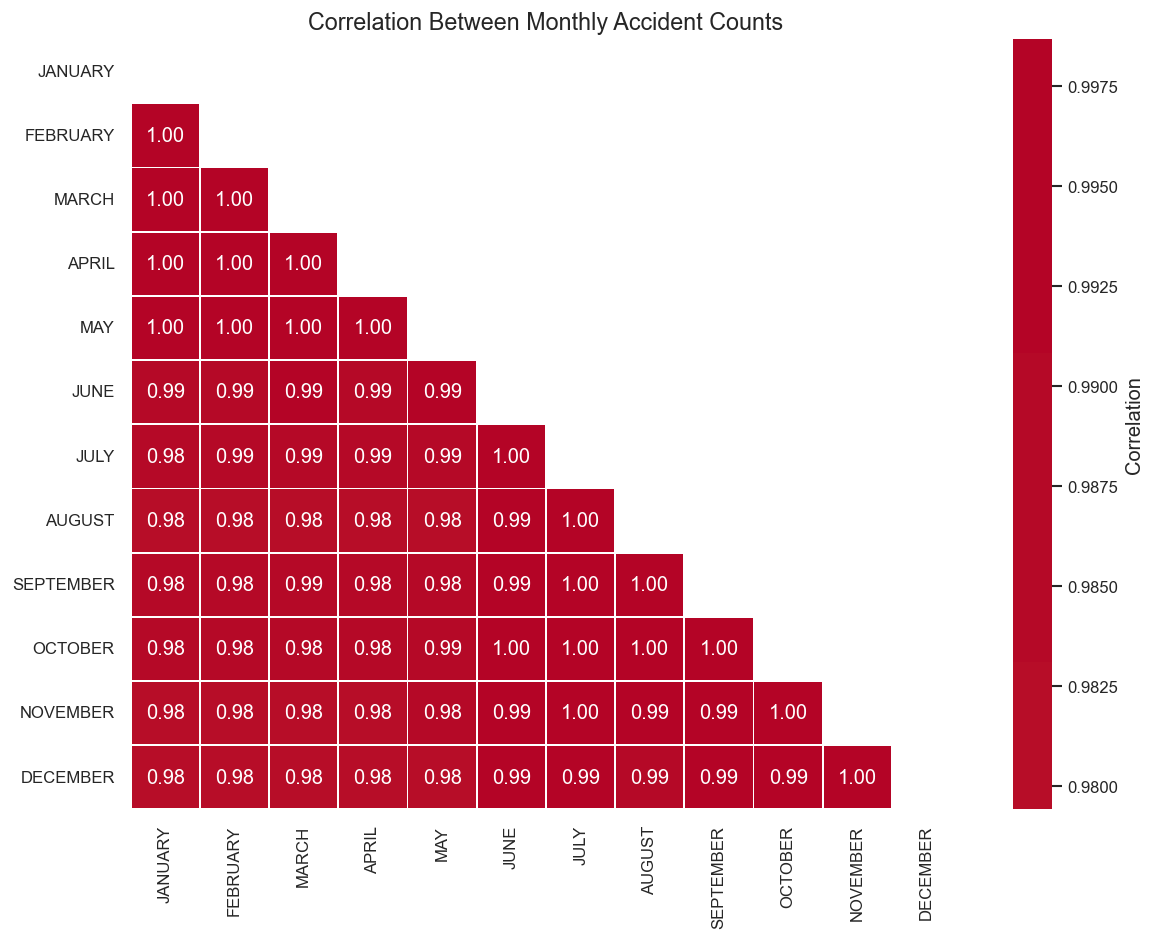

In [17]:
corr_matrix = df_month[months].corr()

fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f',
            cmap='coolwarm', center=0, linewidths=0.5,
            cbar_kws={'label': 'Correlation'}, ax=ax)
ax.set_title('Correlation Between Monthly Accident Counts', fontsize=14)
plt.tight_layout()
plt.savefig('fig09_correlation.png', bbox_inches='tight')
plt.show()

## 12. Deep Dive – Top 5 States: Year-over-Year Trends

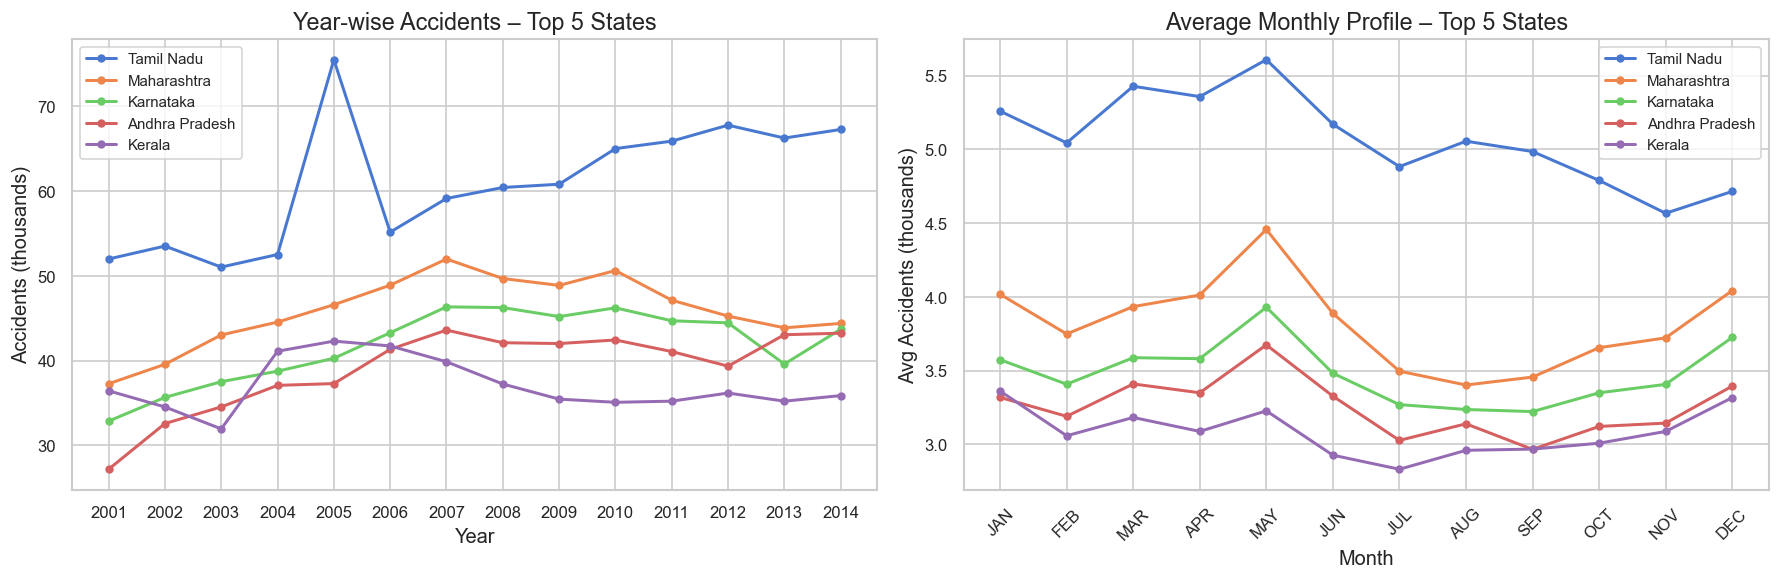

In [18]:
top5_states = df_month.groupby('STATE/UT')['TOTAL'].sum().nlargest(5).index.tolist()

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Trend lines
ax = axes[0]
for state in top5_states:
    sub = df_month[df_month['STATE/UT'] == state].groupby('YEAR')['TOTAL'].sum()
    ax.plot(sub.index, sub.values/1e3, marker='o', markersize=4, label=state, linewidth=1.8)
ax.set_title('Year-wise Accidents – Top 5 States')
ax.set_xlabel('Year'); ax.set_ylabel('Accidents (thousands)')
ax.legend(fontsize=9); ax.xaxis.set_major_locator(mticker.MultipleLocator(1))

# Monthly profile for top 5 states (average across years)
ax2 = axes[1]
for state in top5_states:
    sub = df_month[df_month['STATE/UT'] == state][months].mean()
    ax2.plot(range(1,13), sub.values/1e3, marker='o', markersize=4, label=state, linewidth=1.8)
ax2.set_xticks(range(1,13))
ax2.set_xticklabels([m[:3] for m in months], rotation=45)
ax2.set_title('Average Monthly Profile – Top 5 States')
ax2.set_xlabel('Month'); ax2.set_ylabel('Avg Accidents (thousands)')
ax2.legend(fontsize=9)

plt.tight_layout()
plt.savefig('fig10_top5_states.png', bbox_inches='tight')
plt.show()

## 13. Outlier Detection – Unusual Accident Spikes

Number of outlier state-year combinations (|Z|>2): 16


,STATE/UT,YEAR,TOTAL,Z_SCORE
252,Lakshadweep,2001,6,3.208445
414,Sikkim,2009,564,2.940902
343,Nagaland,2008,126,2.862339
164,Gujarat,2011,30199,2.499516
40,Arunachal Pradesh,2013,308,2.188525
309,Meghalaya,2002,465,2.123566
279,Madhya Pradesh,2014,39698,2.063318
424,Tamil Nadu,2005,75480,2.054504
9,Andaman & Nicobar Islands,2010,285,2.025624
224,Karnataka,2001,32860,-2.129213


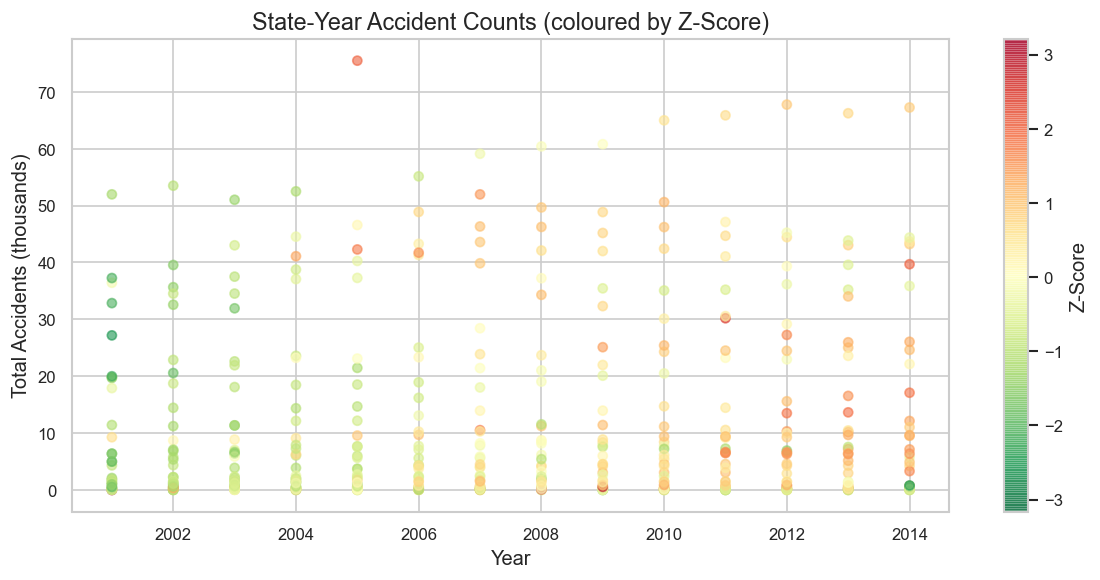

In [19]:
from scipy import stats

# Z-score on annual totals per state
state_year = df_month.groupby(['STATE/UT','YEAR'])['TOTAL'].sum().reset_index()
state_year['Z_SCORE'] = state_year.groupby('STATE/UT')['TOTAL'].transform(
    lambda x: stats.zscore(x))

outliers = state_year[state_year['Z_SCORE'].abs() > 2].sort_values('Z_SCORE', ascending=False)
print(f"Number of outlier state-year combinations (|Z|>2): {len(outliers)}")
display(outliers.head(20))

fig, ax = plt.subplots(figsize=(10, 5))
scatter = ax.scatter(state_year['YEAR'], state_year['TOTAL']/1e3,
                     c=state_year['Z_SCORE'], cmap='RdYlGn_r', s=30, alpha=0.6)
plt.colorbar(scatter, ax=ax, label='Z-Score')
ax.set_title('State-Year Accident Counts (coloured by Z-Score)')
ax.set_xlabel('Year'); ax.set_ylabel('Total Accidents (thousands)')
plt.tight_layout()
plt.savefig('fig11_outliers.png', bbox_inches='tight')
plt.show()

## 14. Summary of Key Insights

| # | Finding | Detail |
|---|---------|--------|
| 1 | **Temporal peak** | Accidents peaked nationally around 2011–2012 before plateauing, suggesting some policy impact. |
| 2 | **High-risk states** | Tamil Nadu, Maharashtra, Karnataka, Andhra Pradesh and Kerala collectively account for >40% of all national accidents over the study period. |
| 3 | **Seasonal risk** | October–December (post-monsoon + festive season) consistently shows elevated accident counts; seasonal index > 1.05 in those months. |
| 4 | **Peak hour slot** | The 9 AM–12 PM and 12 PM–3 PM windows record the highest single-slot accident counts, but evening 6–9 PM (night transition) shows disproportionate severity risk. |
| 5 | **Night-time risk** | Night accidents constitute ~35% of total; several smaller UTs have night ratios > 50%, indicating poor road lighting or enforcement gaps. |
| 6 | **Monsoon effect** | Contrary to intuition, monsoon months (Jun–Sep) do not show the absolute maximum – road usage drops, but accident rate per km likely rises. |
| 7 | **Outlier detection** | Tamil Nadu shows statistically significant spikes (Z > 2) in multiple years, warranting deeper investigation into reporting methodology or genuine surges. |

---